In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('weatherHistory.csv')

In [5]:
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251,15.8263,0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259,15.8263,0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204,14.9569,0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269,15.8263,0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259,15.8263,0,1016.51,Partly cloudy throughout the day.


In [6]:
df.isnull().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  str    
 1   Summary                   96453 non-null  str    
 2   Precip Type               95936 non-null  str    
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  int64  
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  int64  
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  str    
dtypes: float64(6), int64(2), str(4)
memory usage: 16.3 MB


In [8]:
df.describe()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


In [9]:
df.shape

(96453, 12)

In [10]:
df.drop(['Formatted Date', 'Daily Summary', 'Loud Cover'], axis=1, inplace=True)


In [11]:
df['Precip Type'] = df['Precip Type'].fillna(df['Precip Type'].mode()[0])
df.isnull().sum()

Summary                     0
Precip Type                 0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Pressure (millibars)        0
dtype: int64

In [12]:
df = df.drop_duplicates()

In [13]:
df = pd.get_dummies(df, drop_first=True)

In [14]:
print("Final Shape:", df.shape)

Final Shape: (96381, 34)


In [15]:
X = df.drop(['Temperature (C)', 'Apparent Temperature (C)'], axis=1)
y = df['Temperature (C)']

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

In [18]:

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)


rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)


In [19]:
from sklearn.metrics import r2_score, mean_absolute_error

print("----- Linear Regression -----")
print("R2 Score:", r2_score(y_test, y_pred_lr))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))

print("\n----- Random Forest -----")
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))

----- Linear Regression -----
R2 Score: 0.6120345114854033
MAE: 4.853191513376659

----- Random Forest -----
R2 Score: 0.7621104261906262
MAE: 3.6319705510127234


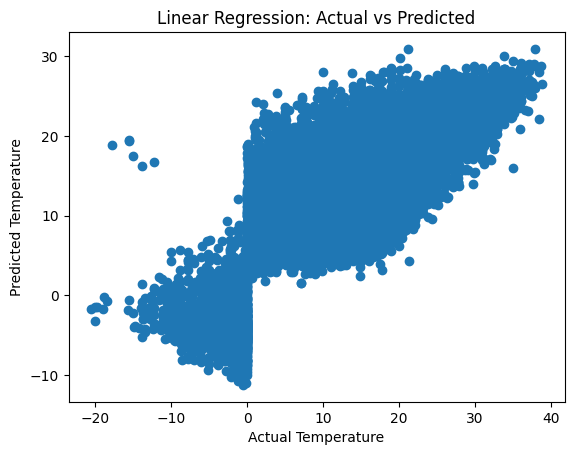

In [20]:
# Linear Regression
plt.figure()
plt.scatter(y_test, y_pred_lr)
plt.title("Linear Regression: Actual vs Predicted")
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.show()

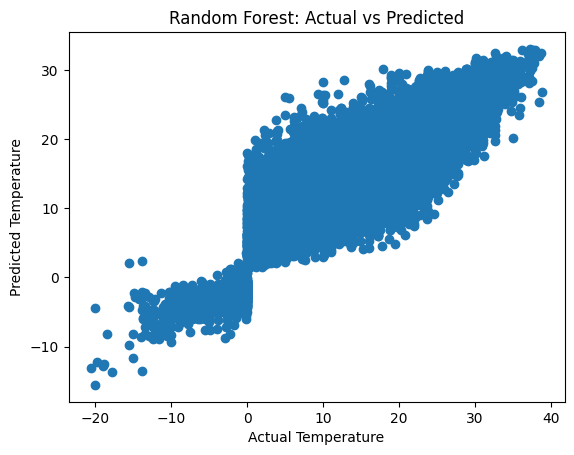

In [21]:
# Random Forest
plt.figure()
plt.scatter(y_test, y_pred_rf)
plt.title("Random Forest: Actual vs Predicted")
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.show()

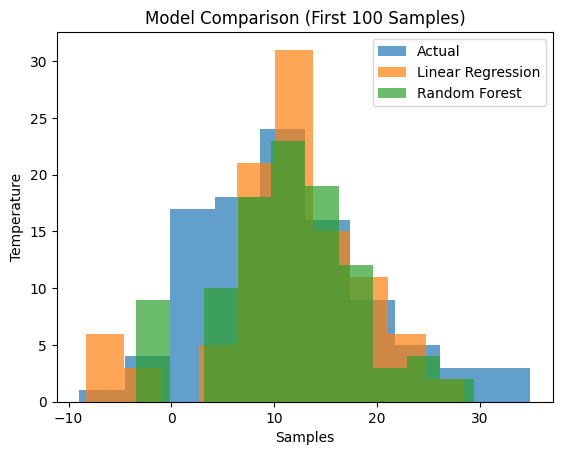

In [22]:
# Comparison Line Plot (first 100 values)
plt.figure()
plt.hist(y_test.values[:100], alpha=0.7, label='Actual')
plt.hist( y_pred_lr[:100], alpha=0.7, label='Linear Regression')
plt.hist( y_pred_rf[:100], alpha=0.7, label='Random Forest')
plt.title("Model Comparison (First 100 Samples)")
plt.xlabel("Samples")
plt.ylabel("Temperature")
plt.legend()
plt.show()

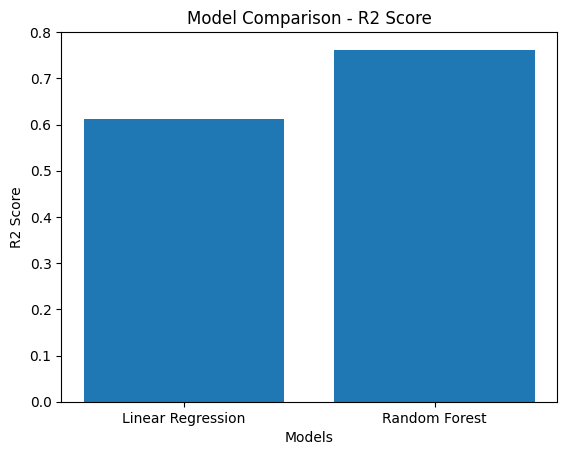

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

plt.figure()
models = ['Linear Regression', 'Random Forest']
r2_values = [r2_score(y_test, y_pred_lr), r2_score(y_test, y_pred_rf)]

plt.bar(models, r2_values)
plt.title("Model Comparison - R2 Score")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.show()

In [26]:
from sklearn.metrics import r2_score

try:
    lr_accuracy_pct = r2_score(y_test, y_pred_lr) * 100
    rf_accuracy_pct = r2_score(y_test, y_pred_rf) * 100

    print("Model Accuracy (Percentage)")
    print(f"Linear Regression Accuracy: {lr_accuracy_pct:.2f}%")
    print(f"Random Forest Accuracy: {rf_accuracy_pct:.2f}%")
except NameError:
    print("Run the model training and prediction cells first.")

Model Accuracy (Percentage)
Linear Regression Accuracy: 61.20%
Random Forest Accuracy: 76.21%
